# Импорт библиотек

In [166]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Обработка входных данных

In [167]:
file = pd.read_csv('DailyDelhiCLimateTrain.csv')
file.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


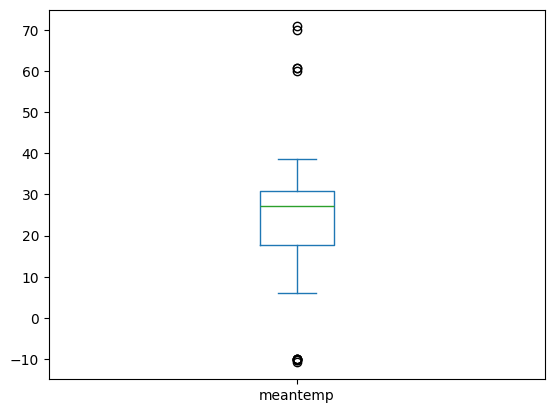

In [168]:
file['meantemp'].plot(kind='box')
plt.show()

<Axes: >

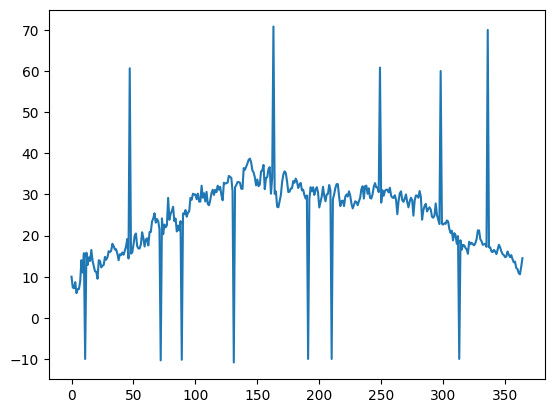

In [169]:
file['meantemp'].plot(kind = 'line')

In [170]:
x = file.index.to_numpy()
y = file['meantemp'].to_numpy()

# Аппроксимация зависимости

## Определение функций

In [171]:
def W_biquadratic(z):
    ''' Биквадратная функция '''
    if abs(z) < 1:
        return (1 - z * z) ** 2
    else:
        return 0

def W_tricubic(z):
    ''' Трикубическая функция '''
    if abs(z) < 1:
        return (1 - abs(z) ** 3) ** 3
    else:
        return 0

In [172]:
def LSM_linear(model, weights, x, y, x_i = 'none'):
    if model == 'lin':
        matrix = np.array([[np.sum(x*x*weights), np.sum(weights * x)], [np.sum(weights*x), np.sum(weights)]])
        column = np.array([np.sum(x*y*weights), np.sum(weights*y)])
        a, b = np.linalg.solve(matrix,column)
        if x_i == 'none':
            return a * x + b
        else:
            return a * x_i + b
    elif model == 'quad':
        matrix = np.array([
            [np.sum(x*x*x*x*weights), np.sum(x*x*x*weights), np.sum(x*x*weights)],
            [np.sum(x*x*x*weights), np.sum(x*x*weights), np.sum(x*weights)],
            [np.sum(x*x*weights), np.sum(x*weights), np.sum(weights)]
        ])
        column = np.array([np.sum(weights*y*x*x), np.sum(weights*y*x), np.sum(weights*y)])
        a, b, c = np.linalg.solve(matrix,column)
        if x_i == 'none':
            return a * x * x + b * x + c
        else:
            return a * x_i * x_i + b * x_i + c

## Начальные параметры

In [173]:
N = len(x) #Размер выборки 
B = 0.05 #коэф сглаживания
r = round(B * N)
print(" Коэффициент сглаживания:", B)
print(" Размер интервала r:", r)

model = "quad"
if model == 'lin':
    print(" Используемая модель для регрессии – линейная")
elif model == "quad":
    print(" Используемая модель для регрессии – квадратичная")

 Коэффициент сглаживания: 0.05
 Размер интервала r: 18
 Используемая модель для регрессии – квадратичная


## LOESS

In [174]:
y_smoothed = np.array([]) # массив точек сглаженных данных

i = 0 # переменная для перебора точек x

while (i < N):
    x_i = x[i] # выберем точку - центр интервала
    # зададим границы локальной окрестности
    if (i < r):
        left_border = 0
        right_border = i + r
    elif (i > N - r):
        left_border = i - r
        right_border = N
    else:
        left_border = i - r
        right_border = i + r
    # зададим диапазон локальной окрестности 
    x_local = x[left_border:right_border + 1]
    y_local = y[left_border:right_border + 1]

    # найдём максимальное расстояние h
    h_max = -1
    for k in range(len(x_local)):
        if abs(x_local[k] - x_i) > h_max:
            h_max = abs(x_local[k] - x_i)
    
    # создадим массив весов каждой точки в диапазоне
    weights = np.array([W_tricubic((x_local[k] - x_i)/h_max) for k in range(len(x_local))])
    
    # вычислим значение сглаженной функции в точке x_i
    
    y_smoothed = np.append(y_smoothed, LSM_linear(model, weights, x_local, y_local, x_i))

    i += 1 

## LOWESS

In [175]:
y_smoothed_robust = np.array([]) # массив точек сглаженных данных

i = 0 # переменная для перебора точек x

while (i < N):
    x_i = x[i] # выберем точку - центр интервала
    # зададим границы локальной окрестности
    if (i < r):
        left_border = 0
        right_border = i + r
    elif (i > N - r):
        left_border = i - r
        right_border = N
    else:
        left_border = i - r
        right_border = i + r
    # зададим диапазон локальной окрестности 
    x_local = x[left_border:right_border + 1]
    y_local = y[left_border:right_border + 1]

    # найдём максимальное расстояние h
    h_max = -1
    for k in range(len(x_local)):
        if abs(x_local[k] - x_i) > h_max:
            h_max = abs(x_local[k] - x_i)
    
    # создадим массив весов каждой точки в диапазоне
    weights = np.array([W_biquadratic((x_local[k] - x_i)/h_max) for k in range(len(x_local))])
    
    # добавим устойчивость к выбросам

    # посчитаем точки, предсказанные с помощью построенной регрессии
    y_regr = LSM_linear(model, weights, x_local, y_local)

    # посчитаем остатки r_j и медианное абсолютное отклонение MAD
    e_j = y_local - y_regr
    e = np.median(e_j)
    MAD = np.median(abs(e_j - e))
    
    # высчитаем новые робастные веса
    robust_weights = np.array([W_biquadratic((e_j[k]/6/MAD)) for k in range(len(e_j))])

    # вычислим значение сглаженной функции в точке x_i (с робастными весами)
    
    y_smoothed_robust = np.append(y_smoothed_robust, LSM_linear(model, robust_weights, x_local, y_local, x_i))

    i += 1 

# Результаты

Text(0.5, 1.0, 'Beta = 0.05')

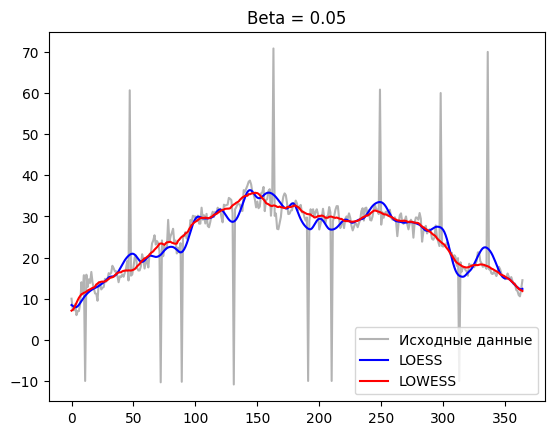

In [176]:
plt.plot(file.index, file['meantemp'], color=(0.7,0.7,0.7), label = "Исходные данные")
plt.plot(x, y_smoothed, color = 'blue', label = "LOESS")
plt.plot(x, y_smoothed_robust, color = 'red', label = "LOWESS")
plt.legend(loc = 'lower right')
plt.title("Beta = " + str(B))